In [135]:
import pandas as pd
import numpy as np
import yfinance as yf

In [136]:
df = yf.download("BTC-USD", period="2y")
df.columns = df.columns.droplevel(1)

[*********************100%***********************]  1 of 1 completed


In [137]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2024-05-17,67051.875000,67459.460938,65119.316406,65231.296875,28031279310
2024-05-18,66940.804688,67387.328125,66663.500000,67066.210938,16712277406
2024-05-19,66278.367188,67694.296875,65937.179688,66937.929688,19249094538
2024-05-20,71448.195312,71483.562500,66086.171875,66278.742188,43850655717
2024-05-21,70136.531250,71946.460938,69191.125000,71443.062500,46932005990


In [138]:
df['close_log_return'] = np.log(df["Close"]/df["Close"].shift())

<Axes: xlabel='Date'>

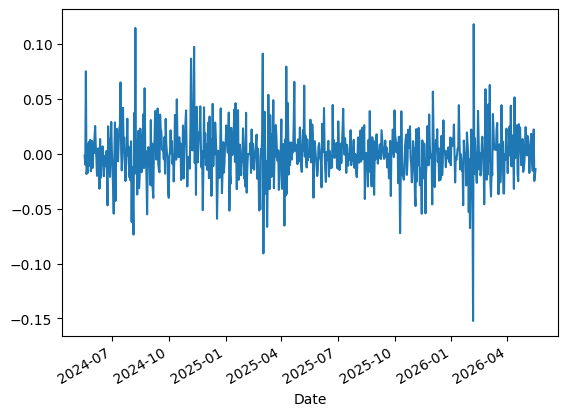

In [139]:
df['close_log_return'].plot()

In [140]:
df["close_log_return_lag1"] = df["close_log_return"].shift()
df.head()

Price,Close,High,Low,Open,Volume,close_log_return,close_log_return_lag1
Date,,,,,,,
2024-05-17,67051.875000,67459.460938,65119.316406,65231.296875,28031279310,NaN,NaN
2024-05-18,66940.804688,67387.328125,66663.500000,67066.210938,16712277406,-0.001658,NaN
2024-05-19,66278.367188,67694.296875,65937.179688,66937.929688,19249094538,-0.009945,-0.001658
2024-05-20,71448.195312,71483.562500,66086.171875,66278.742188,43850655717,0.075109,-0.009945
2024-05-21,70136.531250,71946.460938,69191.125000,71443.062500,46932005990,-0.018529,0.075109


In [141]:
df["close_log_return_dir_lag1"] = df["close_log_return_lag1"].map(lambda x: 1 if x > 0 else -1)

In [142]:
df.head()

Price,Close,High,Low,Open,Volume,close_log_return,close_log_return_lag1,close_log_return_dir_lag1
Date,,,,,,,,
2024-05-17,67051.875000,67459.460938,65119.316406,65231.296875,28031279310,NaN,NaN,-1
2024-05-18,66940.804688,67387.328125,66663.500000,67066.210938,16712277406,-0.001658,NaN,-1
2024-05-19,66278.367188,67694.296875,65937.179688,66937.929688,19249094538,-0.009945,-0.001658,-1
2024-05-20,71448.195312,71483.562500,66086.171875,66278.742188,43850655717,0.075109,-0.009945,-1
2024-05-21,70136.531250,71946.460938,69191.125000,71443.062500,46932005990,-0.018529,0.075109,1


In [143]:
df.groupby('close_log_return_dir_lag1').agg({"close_log_return": ["sum", "mean", "count"]})

Price                     close_log_return                
                                       sum      mean count
close_log_return_dir_lag1                                 
-1                                0.100753  0.000276   365
 1                                0.049912  0.000137   364

In [144]:
i = int(len(df) * 0.75)
in_sample, out_sample = df.iloc[:i], df.iloc[i:]

In [145]:
in_sample.head()

Price,Close,High,Low,Open,Volume,close_log_return,close_log_return_lag1,close_log_return_dir_lag1
Date,,,,,,,,
2024-05-17,67051.875000,67459.460938,65119.316406,65231.296875,28031279310,NaN,NaN,-1
2024-05-18,66940.804688,67387.328125,66663.500000,67066.210938,16712277406,-0.001658,NaN,-1
2024-05-19,66278.367188,67694.296875,65937.179688,66937.929688,19249094538,-0.009945,-0.001658,-1
2024-05-20,71448.195312,71483.562500,66086.171875,66278.742188,43850655717,0.075109,-0.009945,-1
2024-05-21,70136.531250,71946.460938,69191.125000,71443.062500,46932005990,-0.018529,0.075109,1


In [146]:
out_sample.head()

Price,Close,High,Low,Open,Volume,close_log_return,close_log_return_lag1,close_log_return_dir_lag1
Date,,,,,,,,
2025-11-15,95549.148438,96728.468750,94420.468750,94420.468750,38500716654,0.012123,-0.054623,-1
2025-11-16,94177.078125,96564.187500,92971.164062,95556.867188,71086235862,-0.014464,0.012123,1
2025-11-17,92093.875000,95928.367188,91214.757812,94180.875000,94186165724,-0.022368,-0.014464,-1
2025-11-18,92948.875000,93745.078125,89300.460938,92094.531250,101333569062,0.009241,-0.022368,-1
2025-11-19,91465.992188,92946.164062,88526.828125,92946.164062,80350354656,-0.016082,0.009241,1


In [147]:
in_sample.groupby('close_log_return_dir_lag1').agg({"close_log_return": ["sum", "mean", "count"]})

Price                     close_log_return                
                                       sum      mean count
close_log_return_dir_lag1                                 
-1                                0.237684  0.000877   271
 1                                0.104367  0.000380   275

In [148]:
out_sample.groupby('close_log_return_dir_lag1').agg({"close_log_return": ["sum", "mean", "count"]})

Price                     close_log_return                
                                       sum      mean count
close_log_return_dir_lag1                                 
-1                               -0.136932 -0.001457    94
 1                               -0.054454 -0.000612    89

In [149]:
df["signal"] = -1 * df["close_log_return_dir_lag1"]

In [150]:
df["trade_log_return"] = df["signal"] * df["close_log_return"]

In [151]:
df.head()

Price,Close,High,Low,Open,Volume,close_log_return,close_log_return_lag1,close_log_return_dir_lag1,signal,trade_log_return
Date,,,,,,,,,,
2024-05-17,67051.875000,67459.460938,65119.316406,65231.296875,28031279310,NaN,NaN,-1,1,NaN
2024-05-18,66940.804688,67387.328125,66663.500000,67066.210938,16712277406,-0.001658,NaN,-1,1,-0.001658
2024-05-19,66278.367188,67694.296875,65937.179688,66937.929688,19249094538,-0.009945,-0.001658,-1,1,-0.009945
2024-05-20,71448.195312,71483.562500,66086.171875,66278.742188,43850655717,0.075109,-0.009945,-1,1,0.075109
2024-05-21,70136.531250,71946.460938,69191.125000,71443.062500,46932005990,-0.018529,0.075109,1,-1,0.018529


In [152]:
df["cum_trade_log_ret"] = df["trade_log_return"].cumsum()

<Axes: xlabel='Date'>

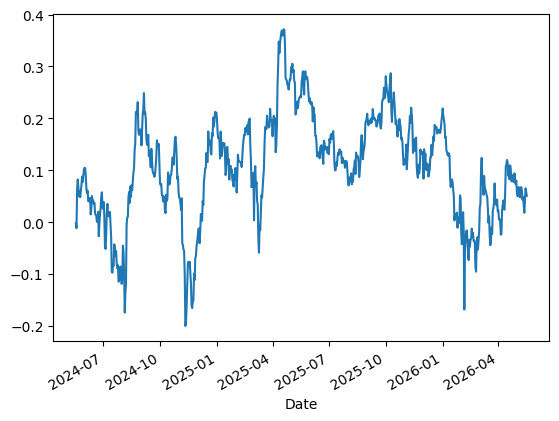

In [153]:
df["cum_trade_log_ret"].plot()

In [154]:
df["is_won"] = df["trade_log_return"] > 0

In [155]:
df.head()

Price,Close,High,Low,Open,Volume,close_log_return,close_log_return_lag1,close_log_return_dir_lag1,signal,trade_log_return,cum_trade_log_ret,is_won
Date,,,,,,,,,,,,
2024-05-17,67051.875000,67459.460938,65119.316406,65231.296875,28031279310,NaN,NaN,-1,1,NaN,NaN,False
2024-05-18,66940.804688,67387.328125,66663.500000,67066.210938,16712277406,-0.001658,NaN,-1,1,-0.001658,-0.001658,False
2024-05-19,66278.367188,67694.296875,65937.179688,66937.929688,19249094538,-0.009945,-0.001658,-1,1,-0.009945,-0.011603,False
2024-05-20,71448.195312,71483.562500,66086.171875,66278.742188,43850655717,0.075109,-0.009945,-1,1,0.075109,0.063506,True
2024-05-21,70136.531250,71946.460938,69191.125000,71443.062500,46932005990,-0.018529,0.075109,1,-1,0.018529,0.082035,True


In [156]:
df["is_won"].mean()

np.float64(0.4986301369863014)

In [157]:
r = np.exp(df["trade_log_return"].sum()) - 1

In [158]:
r

np.float64(0.05215525702095447)

## With Z Score

In [284]:
window = 10

In [285]:
df["rolling_mean"] = df["close_log_return"].rolling(window).mean()
df["rolling_std"] = df["close_log_return"].rolling(window).std()

In [286]:
df

Price,Close,High,Low,Open,Volume,close_log_return,close_log_return_lag1,close_log_return_dir_lag1,signal,trade_log_return,cum_trade_log_ret,is_won,rolling_mean,rolling_std,zscore,zscore_lag1,z_trade_log_return,z_cum_trade_log_return,bh_cum_return
Date,,,,,,,,,,,,,,,,,,,
2024-05-17,67051.875000,67459.460938,65119.316406,65231.296875,28031279310,NaN,NaN,-1,0,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-18,66940.804688,67387.328125,66663.500000,67066.210938,16712277406,-0.001658,NaN,-1,0,-0.001658,-0.001658,False,NaN,NaN,NaN,NaN,-0.0,0.000000,-0.001658
2024-05-19,66278.367188,67694.296875,65937.179688,66937.929688,19249094538,-0.009945,-0.001658,-1,0,-0.009945,-0.011603,False,NaN,NaN,NaN,NaN,-0.0,0.000000,-0.011603
2024-05-20,71448.195312,71483.562500,66086.171875,66278.742188,43850655717,0.075109,-0.009945,-1,0,0.075109,0.063506,True,NaN,NaN,NaN,NaN,0.0,0.000000,0.063506
2024-05-21,70136.531250,71946.460938,69191.125000,71443.062500,46932005990,-0.018529,0.075109,1,0,0.018529,0.082035,True,NaN,NaN,NaN,NaN,-0.0,0.000000,0.044977
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-12,80477.492188,81753.031250,79832.101562,81725.351562,32186688600,-0.015423,-0.005012,-1,0,-0.015423,0.033081,False,0.002288,0.012383,-1.372830,-0.668506,-0.0,0.228372,0.182511
2026-05-13,79277.117188,81276.671875,78725.507812,80476.789062,34075428359,-0.015028,-0.015423,-1,0,-0.015028,0.018053,False,0.000936,0.013528,-1.222195,-1.372830,-0.0,0.228372,0.167483
2026-05-14,81051.250000,82005.960938,78909.679688,79276.945312,43731663431,0.022132,-0.015028,-1,0,0.022132,0.040185,True,0.001521,0.014365,1.483046,-1.222195,0.0,0.228372,0.189615


In [287]:
df["zscore"] = (df["close_log_return"] - df["rolling_mean"]) / df["rolling_std"]

<Axes: xlabel='Date'>

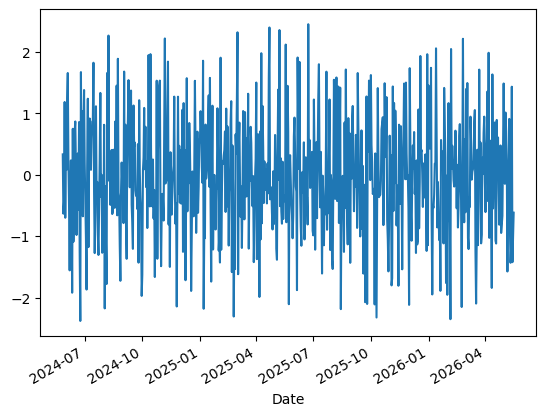

In [288]:
df["zscore"].plot()

In [289]:
df["zscore_lag1"] = df["zscore"].shift()

In [300]:
threshold = 1.75
df["signal"] = df["zscore_lag1"].map(lambda x: -1 if x > threshold else (1 if x < -threshold else 0))

In [301]:
df["z_trade_log_return"] = df["signal"] * df["close_log_return"]

In [302]:
df["z_cum_trade_log_return"] = df["z_trade_log_return"].cumsum()

<Axes: xlabel='Date'>

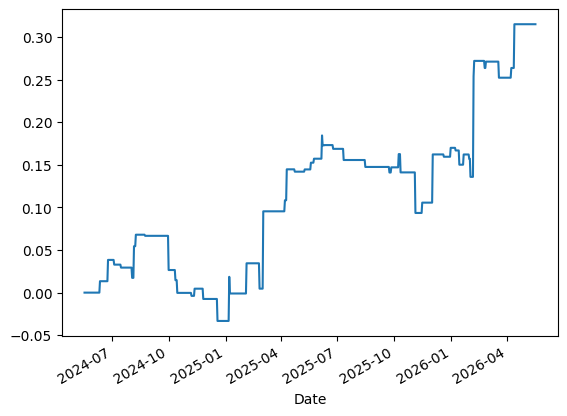

In [303]:
df["z_cum_trade_log_return"].plot()

In [304]:
df["bh_cum_return"] = df["close_log_return"].cumsum()

<Axes: xlabel='Date'>

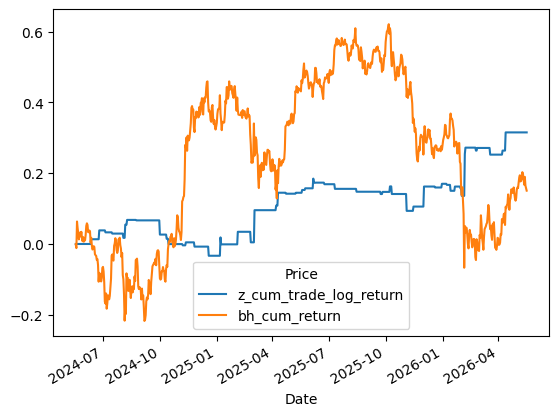

In [305]:
df[["z_cum_trade_log_return", "bh_cum_return"]].plot()

In [306]:
z_r = np.exp(df["z_trade_log_return"].sum()) - 1
bh_r = np.exp(df["close_log_return"].sum()) - 1

In [307]:
z_r

np.float64(0.37059400552569666)

In [308]:
bh_r

np.float64(0.16260730963899128)

In [310]:
df["z_trade_log_return"].mean() / df["z_trade_log_return"].std() * np.sqrt(365)

np.float64(1.034522565789126)